In [25]:
%load_ext autoreload
%autoreload 2

The autoreload extension is already loaded. To reload it, use:
  %reload_ext autoreload


In [26]:
from nca.model import *
from nca.rollout import *
from nca.viz import *
from nca.stats import *

import torch
import numpy as np
import imageio
from IPython.display import Image, display
from IPython.display import Video

In [28]:
device = torch.device("cpu")
model = NCA()
state = torch.load("../../snapshots/froggy_model_with_regen.pth", map_location=device)
model.load_state_dict(state)
model.eval()  # VERY IMPORTANT

NCA(
  (net): Sequential(
    (0): Conv2d(64, 128, kernel_size=(1, 1), stride=(1, 1))
    (1): ReLU()
    (2): Conv2d(128, 16, kernel_size=(1, 1), stride=(1, 1), bias=False)
  )
)

In [33]:
x0 = seed(1)  # initial seed, shape [1, C, H, W]
with torch.no_grad():
    states = rollout(
        model,
        x0,
        steps=300,
        ablate_channel=None,
        width_cut=None,
        killEye=150,
        prune=False,
        realEyeReplace=None,
        realEyeCapture=None,
        fakeEyeReplace=None,
        inhibit=None
    )

In [34]:
frames = [frame_to_rgb_uint8(f[:4]) for f in states] # Select first 4 channels (RGBA) and convert

save_crisp_mp4(
    frames,
    output_file="output.mp4",
    fps=60,
    upscale=1,
    frames_dir="frames", 
    quiet=True
)

# local file
Video("output.mp4", embed=True, width=400, height=400)

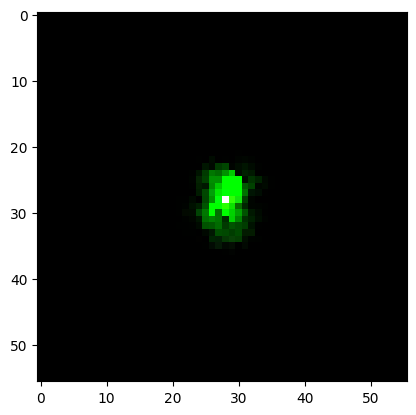

In [24]:
plt.imshow(frames[15])